# 13C Test: CNN Fine-Tune Checkpoint

Load a persisted 13C commutative CNN fine-tune checkpoint and run evaluation only. This notebook can use the best scored checkpoint across CNN campaign trials, the newest checkpoint across trials, or the best checkpoint from the latest active trial. It does not train or update model weights.


In [78]:
%load_ext autoreload
%autoreload 2


from dataclasses import asdict
from datetime import datetime
import json
from pathlib import Path

try:
    from IPython.display import display
except ImportError:
    def display(value):
        print(value)
import numpy as np
import pandas as pd
import torch

from src.dataset_config import load_current_dataset_artifact_path
from src.ml import (
    CommutativeCNNClassifier,
    LossWeightConfig,
    OptimizationConfig,
    create_experiment_run,
    display_experiment_summary,
    display_holdout_evaluation,
    prepare_multitask_experiment_data,
)
from src.models.configs import CommutativeCNNConfig
from src.training.reporting import build_confusion_matrix_frames
from src.tensor_utils import (
    build_tensor_embedding_2d,
    load_labeled_tensor_dataset,
    plot_tensor_embedding_2d,
)

pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", None)
pd.set_option("display.width", None)
pd.set_option("display.expand_frame_repr", False)


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [79]:
# User inputs

campaign_root = Path("artifacts/campaigns/cnn_pretrain_finetune")

# Options:
# - "best_checkpoint" or "best": best scored persisted 13C checkpoint across all CNN campaign trials.
# - "last_checkpoint", "latest_checkpoint", or "last": newest persisted 13C checkpoint across all CNN campaign trials.
# - "latest_trial": best scored 13C checkpoint from the current/latest campaign trial only.
checkpoint_selection_mode = "last_checkpoint"

selection_target = "compound"
selection_metric = "macro_f1"
fallback_selection_metrics = ["weighted_f1", "accuracy", "roc_auc_ovr_macro", "average_precision_macro"]

test_output_dir = Path("artifacts/nb13C_commutative_cnn_test")
umap_method = "umap"
umap_n_neighbors = 15  # Smaller values make tighter local clumps; larger values preserve broader structure.
umap_min_dist = 0.1  # Smaller values pack points more tightly; larger values spread clusters out.


In [80]:
def _read_json(path: Path) -> dict:
    return json.loads(path.read_text(encoding="utf-8"))


def _latest_campaign_trial(campaign_root: Path) -> Path:
    if not campaign_root.exists():
        raise FileNotFoundError(f"Campaign root does not exist: {campaign_root}")
    state_path = campaign_root / "campaign_state.json"
    if state_path.exists():
        state = _read_json(state_path)
        trial_dir = state.get("current_trial_dir")
        if trial_dir and Path(trial_dir).exists():
            return Path(trial_dir)
    trial_dirs = _all_campaign_trials(campaign_root)
    if not trial_dirs:
        raise FileNotFoundError(f"No CNN campaign trial directories found in {campaign_root}")
    return trial_dirs[-1]


def _all_campaign_trials(campaign_root: Path) -> list[Path]:
    if not campaign_root.exists():
        raise FileNotFoundError(f"Campaign root does not exist: {campaign_root}")
    return sorted(
        path for path in campaign_root.iterdir()
        if path.is_dir() and path.name.startswith("cnn_pretrain_finetune_")
    )


def _candidate_config_path(run_dir: Path, experiment_id: str) -> Path | None:
    for suffix in ("json", "yaml", "yml"):
        path = run_dir / f"{experiment_id}_config.{suffix}"
        if path.exists():
            return path
    configs = sorted(run_dir.glob("*config.json")) + sorted(run_dir.glob("*config.yaml")) + sorted(run_dir.glob("*config.yml"))
    return configs[0] if configs else None


def _load_config(path: Path) -> dict:
    if path.suffix.lower() == ".json":
        return _read_json(path)
    try:
        import yaml
    except ImportError as exc:
        raise ImportError(f"PyYAML is required to read {path}") from exc
    payload = yaml.safe_load(path.read_text(encoding="utf-8"))
    return payload or {}


def _load_summary_score(summary_path: Path, target: str, metric: str, fallbacks: list[str]) -> tuple[float, str] | None:
    if not summary_path.exists():
        return None
    summary_df = pd.read_csv(summary_path)
    if not {"target", "metric", "value"}.issubset(summary_df.columns):
        return None
    target_df = summary_df[summary_df["target"].astype(str).eq(target)].copy()
    if target_df.empty:
        return None
    for metric_name in [metric, *fallbacks]:
        rows = target_df[target_df["metric"].astype(str).eq(metric_name)]
        if not rows.empty:
            return float(rows.iloc[0]["value"]), metric_name
    return None


def _trial_from_run_dir(run_dir: Path) -> Path | None:
    parts = run_dir.parts
    for index, part in enumerate(parts):
        if part == "outputs" and index > 0:
            return Path(*parts[:index])
    return None


def _checkpoint_file_info(checkpoint_path: Path) -> dict:
    stat = checkpoint_path.stat()
    return {
        "checkpoint_path": checkpoint_path,
        "checkpoint_resolved_path": checkpoint_path.resolve(),
        "checkpoint_name": checkpoint_path.name,
        "checkpoint_size_bytes": int(stat.st_size),
        "checkpoint_modified_at": datetime.fromtimestamp(stat.st_mtime).isoformat(timespec="seconds"),
    }


def _candidate_row(checkpoint_path: Path, *, selection_mode: str) -> dict:
    run_dir = checkpoint_path.parent
    experiment_id = checkpoint_path.name.removesuffix("_model_state.pt")
    trial_dir = _trial_from_run_dir(run_dir)
    summary_path = run_dir / f"{experiment_id}_summary_metrics.csv"
    config_path = _candidate_config_path(run_dir, experiment_id)
    score = _load_summary_score(summary_path, selection_target, selection_metric, fallback_selection_metrics)
    row = {
        "selection_mode": selection_mode,
        "source_trial": trial_dir,
        "experiment_id": experiment_id,
        "run_dir": run_dir,
        "checkpoint_path": checkpoint_path,
        "config_path": config_path,
        "summary_path": summary_path if summary_path.exists() else None,
        "score": None if score is None else score[0],
        "score_metric": None if score is None else score[1],
        "checkpoint_mtime": checkpoint_path.stat().st_mtime,
    }
    row.update(_checkpoint_file_info(checkpoint_path))
    return row


def _discover_13c_candidates_in_trial(trial_dir: Path, *, selection_mode: str) -> pd.DataFrame:
    rows = [
        _candidate_row(checkpoint_path, selection_mode=selection_mode)
        for checkpoint_path in sorted(trial_dir.glob("outputs/13C/runs/*/*_model_state.pt"))
    ]
    return pd.DataFrame(rows)


def _discover_all_13c_candidates(campaign_root: Path, *, selection_mode: str) -> pd.DataFrame:
    rows = []
    for trial_dir in _all_campaign_trials(campaign_root):
        for checkpoint_path in sorted(trial_dir.glob("outputs/13C/runs/*/*_model_state.pt")):
            rows.append(_candidate_row(checkpoint_path, selection_mode=selection_mode))
    return pd.DataFrame(rows)


def _select_best_candidate(candidates: pd.DataFrame, *, latest_trial: Path | None) -> pd.Series:
    if candidates.empty:
        campaign_state_path = campaign_root / "campaign_state.json"
        state = _read_json(campaign_state_path) if campaign_state_path.exists() else {}
        stage_states = {}
        if latest_trial is not None and latest_trial.exists():
            stage_states = {path.stem: _read_json(path) for path in sorted(latest_trial.glob("stage_state/*.json"))}
        message = (
            "No persisted 13C fine-tune checkpoint was found for the selected mode.\n"
            f"Selection mode: {checkpoint_selection_mode}\n"
            f"Latest trial: {latest_trial}\n"
            f"Campaign status: {state.get('status')} / phase={state.get('phase')} / current_stage={state.get('current_stage')}\n"
            f"Stage states: {stage_states}\n"
            "Use checkpoint_selection_mode='best_checkpoint' for the best scored checkpoint, "
            "checkpoint_selection_mode='last_checkpoint' for the newest checkpoint, "
            "or checkpoint_selection_mode='latest_trial' for the latest active trial only."
        )
        raise FileNotFoundError(message)
    ranked = candidates.copy()
    ranked["has_score"] = ranked["score"].notna()
    ranked["score_for_rank"] = ranked["score"].fillna(-np.inf)
    ranked = ranked.sort_values(
        ["has_score", "score_for_rank", "checkpoint_mtime"],
        ascending=[False, False, False],
    )
    return ranked.iloc[0]


def _select_last_candidate(candidates: pd.DataFrame, *, latest_trial: Path | None) -> pd.Series:
    if candidates.empty:
        return _select_best_candidate(candidates, latest_trial=latest_trial)
    ranked = candidates.copy()
    ranked = ranked.sort_values("checkpoint_mtime", ascending=False)
    return ranked.iloc[0]


mode = str(checkpoint_selection_mode).strip().lower()
latest_trial = _latest_campaign_trial(campaign_root)
if mode == "latest_trial":
    candidates = _discover_13c_candidates_in_trial(latest_trial, selection_mode=mode)
    selected = _select_best_candidate(candidates, latest_trial=latest_trial)
elif mode in {"best_checkpoint", "best"}:
    candidates = _discover_all_13c_candidates(campaign_root, selection_mode="best_checkpoint")
    selected = _select_best_candidate(candidates, latest_trial=latest_trial)
elif mode in {"last_checkpoint", "latest_checkpoint", "last"}:
    candidates = _discover_all_13c_candidates(campaign_root, selection_mode="last_checkpoint")
    selected = _select_last_candidate(candidates, latest_trial=latest_trial)
else:
    raise ValueError("checkpoint_selection_mode must be one of 'best_checkpoint', 'best', 'last_checkpoint', 'latest_checkpoint', 'last', or 'latest_trial'")

checkpoint_info = {
    key: selected.get(key)
    for key in [
        "selection_mode",
        "source_trial",
        "experiment_id",
        "run_dir",
        "checkpoint_path",
        "checkpoint_resolved_path",
        "checkpoint_name",
        "checkpoint_size_bytes",
        "checkpoint_modified_at",
        "config_path",
        "summary_path",
        "score",
        "score_metric",
    ]
}

print(f"Latest CNN campaign trial: {latest_trial}")
print(f"Checkpoint selection mode: {checkpoint_info['selection_mode']}")
if not candidates.empty:
    display_columns = [
        "selection_mode",
        "source_trial",
        "experiment_id",
        "score_metric",
        "score",
        "checkpoint_modified_at",
        "checkpoint_size_bytes",
        "checkpoint_path",
        "config_path",
    ]
    display(candidates.sort_values(["checkpoint_mtime"], ascending=False)[display_columns])
print(f"Selected experiment: {selected['experiment_id']}")
print(f"Selected checkpoint: {Path(selected['checkpoint_path']).resolve()}")
print(f"Selected config: {Path(selected['config_path']).resolve()}")
print(f"Selection score: {selected['score']} ({selected['score_metric']})")


Latest CNN campaign trial: artifacts/campaigns/cnn_pretrain_finetune/cnn_pretrain_finetune_20260730_120254_2395da
Checkpoint selection mode: last_checkpoint


,selection_mode,source_trial,experiment_id,score_metric,score,checkpoint_modified_at,checkpoint_size_bytes,checkpoint_path,config_path
4,last_checkpoint,artifacts/campaigns/cnn_pretrain_finetune/cnn_pretrain_finetune_20260730_120254_2395da,13C_finetune_commutative_cnn_20260730_120257,None,NaN,2026-07-31T12:08:47,768977,artifacts/campaigns/cnn_pretrain_finetune/cnn_pretrain_finetune_20260730_120254_2395da/outputs/13C/runs/13C_finetune_commutative_cnn_20260730_120257/13C_finetune_commutative_cnn_20260730_120257_model_state.pt,artifacts/campaigns/cnn_pretrain_finetune/cnn_pretrain_finetune_20260730_120254_2395da/outputs/13C/runs/13C_finetune_commutative_cnn_20260730_120257/13C_finetune_commutative_cnn_20260730_120257_config.yaml
3,last_checkpoint,artifacts/campaigns/cnn_pretrain_finetune/cnn_pretrain_finetune_20260704_141700_197670,13C_finetune_commutative_cnn_20260705_131931,macro_f1,0.252809,2026-07-05T22:57:11,773209,artifacts/campaigns/cnn_pretrain_finetune/cnn_pretrain_finetune_20260704_141700_197670/outputs/13C/runs/13C_finetune_commutative_cnn_20260705_131931/13C_finetune_commutative_cnn_20260705_131931_model_state.pt,artifacts/campaigns/cnn_pretrain_finetune/cnn_pretrain_finetune_20260704_141700_197670/outputs/13C/runs/13C_finetune_commutative_cnn_20260705_131931/13C_finetune_commutative_cnn_20260705_131931_config.json
2,last_checkpoint,artifacts/campaigns/cnn_pretrain_finetune/cnn_pretrain_finetune_20260703_031242_495f28,13C_finetune_commutative_cnn_20260704_051554,macro_f1,0.129741,2026-07-04T13:41:58,773209,artifacts/campaigns/cnn_pretrain_finetune/cnn_pretrain_finetune_20260703_031242_495f28/outputs/13C/runs/13C_finetune_commutative_cnn_20260704_051554/13C_finetune_commutative_cnn_20260704_051554_model_state.pt,artifacts/campaigns/cnn_pretrain_finetune/cnn_pretrain_finetune_20260703_031242_495f28/outputs/13C/runs/13C_finetune_commutative_cnn_20260704_051554/13C_finetune_commutative_cnn_20260704_051554_config.json
1,last_checkpoint,artifacts/campaigns/cnn_pretrain_finetune/cnn_pretrain_finetune_20260701_130749_69a864,13C_finetune_commutative_cnn_20260702_151104,macro_f1,0.233239,2026-07-03T02:44:35,773209,artifacts/campaigns/cnn_pretrain_finetune/cnn_pretrain_finetune_20260701_130749_69a864/outputs/13C/runs/13C_finetune_commutative_cnn_20260702_151104/13C_finetune_commutative_cnn_20260702_151104_model_state.pt,artifacts/campaigns/cnn_pretrain_finetune/cnn_pretrain_finetune_20260701_130749_69a864/outputs/13C/runs/13C_finetune_commutative_cnn_20260702_151104/13C_finetune_commutative_cnn_20260702_151104_config.json
0,last_checkpoint,artifacts/campaigns/cnn_pretrain_finetune/cnn_pretrain_finetune_20260629_100031_3ff738,13C_finetune_commutative_cnn_20260701_050638,macro_f1,0.235768,2026-07-01T12:33:14,773209,artifacts/campaigns/cnn_pretrain_finetune/cnn_pretrain_finetune_20260629_100031_3ff738/outputs/13C/runs/13C_finetune_commutative_cnn_20260701_050638/13C_finetune_commutative_cnn_20260701_050638_model_state.pt,artifacts/campaigns/cnn_pretrain_finetune/cnn_pretrain_finetune_20260629_100031_3ff738/outputs/13C/runs/13C_finetune_commutative_cnn_20260701_050638/13C_finetune_commutative_cnn_20260701_050638_config.json


Selected experiment: 13C_finetune_commutative_cnn_20260730_120257
Selected checkpoint: /run/media/fabrizio/06bb7271-2161-43a4-91f1-98f9b67e9ab2/home/fabrizio/code/ZebraFish/artifacts/campaigns/cnn_pretrain_finetune/cnn_pretrain_finetune_20260730_120254_2395da/outputs/13C/runs/13C_finetune_commutative_cnn_20260730_120257/13C_finetune_commutative_cnn_20260730_120257_model_state.pt
Selected config: /run/media/fabrizio/06bb7271-2161-43a4-91f1-98f9b67e9ab2/home/fabrizio/code/ZebraFish/artifacts/campaigns/cnn_pretrain_finetune/cnn_pretrain_finetune_20260730_120254_2395da/outputs/13C/runs/13C_finetune_commutative_cnn_20260730_120257/13C_finetune_commutative_cnn_20260730_120257_config.yaml
Selection score: nan (None)


In [81]:
run_config = _load_config(Path(selected["config_path"]))

model_config = CommutativeCNNConfig(**dict(run_config["model_config"]))
optimization_payload = dict(run_config["optimization_config"])
optimization_payload["device"] = None  # Use the currently available device for evaluation.
optimization_payload["verbose"] = False
optimization_config = OptimizationConfig(**optimization_payload)
loss_weight_config = LossWeightConfig(**dict(run_config["loss_weight_config"]))

dataset_artifact_path = Path(run_config["dataset_artifact_path"]) if run_config.get("dataset_artifact_path") else load_current_dataset_artifact_path()
holdout_fraction = float(run_config.get("holdout_fraction", 0.25))
validation_fraction_within_train = float(run_config.get("validation_fraction_within_train", 0.20))
train_num_random_rotations = int(run_config.get("train_num_random_rotations", 0))
rotation_range_degrees = float(run_config.get("rotation_range_degrees", 0.0))
freeze_backbone = bool(run_config.get("freeze_backbone", False))
hot_start = bool(run_config.get("hot_start", True))

experiment_run = create_experiment_run(test_output_dir, "13C_test_commutative_cnn")
figure_dir = Path(experiment_run.figure_dir)
print(f"Test-only output folder: {Path(experiment_run.run_dir).resolve()}")
print(f"Dataset artifact: {dataset_artifact_path.resolve()}")


Test-only output folder: /run/media/fabrizio/06bb7271-2161-43a4-91f1-98f9b67e9ab2/home/fabrizio/code/ZebraFish/artifacts/nb13C_commutative_cnn_test/runs/13C_test_commutative_cnn_20260731_124607
Dataset artifact: /run/media/fabrizio/06bb7271-2161-43a4-91f1-98f9b67e9ab2/home/fabrizio/code/ZebraFish/.dataset_cache/moa_GA_An_NM_Ac_AC_In_mA_Ag_c2_mca3_mtc16_t20_z5_y96_x96.pt


In [82]:
dataset = load_labeled_tensor_dataset(dataset_artifact_path)
experiment = prepare_multitask_experiment_data(
    dataset,
    holdout_fraction=holdout_fraction,
    validation_fraction_within_train=validation_fraction_within_train,
    train_num_random_rotations=train_num_random_rotations,
    rotation_range_degrees=rotation_range_degrees,
    random_state=optimization_config.random_state,
)
display_experiment_summary(experiment)


,split,n_samples
0,train_augmented,1512
1,train_base,168
2,val,42
3,holdout,71


,mechanism_of_action,compound,concentration_band,n_samples
0,GABAAR_Antagonist,Gabazine,high,63
1,GABAAR_Antagonist,Bemegride,control,63
2,AChE_Inhibitor_Reversible,Galantamine,high,54
3,GABAAR_Antagonist,Gabazine,control,54
4,mAChR_Agonist_NonSelective,Bethanechol,high,54
5,mAChR_Agonist_NonSelective,Bethanechol,mid,54
6,mAChR_Agonist_NonSelective,Muscarine,high,54
7,NMDAR_Activation,Cis-ACPD,control,54
8,mAChR_Agonist_NonSelective,Pilocarpine,high,45
9,mAChR_Agonist_NonSelective,Bethanechol,control,45


In [83]:
model = CommutativeCNNClassifier(
    model_config=model_config,
    optimization_config=optimization_config,
    loss_weight_config=loss_weight_config,
    pretrained_state_path=None,
    freeze_backbone=freeze_backbone,
    hot_start=hot_start,
)

# Rebuild fitted metadata and standardization from the saved run config without running training.
prepared = model._prepare_training_data(
    experiment.X_train,
    experiment.y_train.to_numpy(),
    validation_data=(experiment.splits.X_val, experiment.splits.y_val),
    compound_y=None if experiment.compound_train is None else experiment.compound_train.to_numpy(),
    concentration_y=None if experiment.concentration_train is None else experiment.concentration_train.to_numpy(),
    validation_compound_y=experiment.splits.compound_val,
    validation_concentration_y=experiment.splits.concentration_val,
)
model.model_ = model._build_model_from_prepared(prepared)
model.device_ = model._device()
checkpoint_payload = torch.load(Path(selected["checkpoint_path"]), map_location="cpu")
if isinstance(checkpoint_payload, dict) and "model_state_dict" in checkpoint_payload:
    state_dict = checkpoint_payload["model_state_dict"]
    checkpoint_info.update(
        {
            "checkpoint_format": "payload_with_model_state_dict",
            "payload_keys": sorted(str(key) for key in checkpoint_payload.keys()),
            "best_epoch": checkpoint_payload.get("best_epoch"),
            "best_metric": checkpoint_payload.get("best_metric"),
            "monitor_key": checkpoint_payload.get("monitor_key"),
        }
    )
elif isinstance(checkpoint_payload, dict):
    state_dict = checkpoint_payload
    checkpoint_info.update(
        {
            "checkpoint_format": "raw_state_dict",
            "payload_keys": None,
            "best_epoch": None,
            "best_metric": None,
            "monitor_key": None,
        }
    )
else:
    raise TypeError(f"Unsupported checkpoint payload type: {type(checkpoint_payload).__name__}")
checkpoint_info["state_dict_key_count"] = len(state_dict)
checkpoint_info["state_dict_tensor_count"] = int(sum(1 for value in state_dict.values() if isinstance(value, torch.Tensor)))

missing_keys, unexpected_keys = model.model_.load_state_dict(state_dict, strict=False)
if missing_keys or unexpected_keys:
    raise RuntimeError(
        f"Checkpoint did not match reconstructed model. missing={missing_keys}, unexpected={unexpected_keys}"
    )
model.model_.to(model.device_)
model.model_.eval()

history_path = Path(selected["run_dir"]) / f"{selected['experiment_id']}_history.csv"
if history_path.exists():
    model.history_ = pd.read_csv(history_path)
    checkpoint_info["history_path"] = history_path
    checkpoint_info["history_rows"] = int(len(model.history_))
else:
    checkpoint_info["history_path"] = None
    checkpoint_info["history_rows"] = None

checkpoint_info_df = pd.DataFrame([checkpoint_info])
display(checkpoint_info_df.T.rename(columns={0: "value"}))

print(f"Loaded checkpoint on {model.device_}")
print(f"Action classes: {dict(zip(model.classes_, [experiment.label_maps['action'][int(k)] for k in model.classes_]))}")
if getattr(model, "compound_classes_", None) is not None:
    print(f"Compound classes: {dict(zip(model.compound_classes_, [experiment.label_maps['compound'][int(k)] for k in model.compound_classes_]))}")
if getattr(model, "concentration_classes_", None) is not None:
    print(f"Concentration classes: {dict(zip(model.concentration_classes_, [experiment.label_maps['concentration'][int(k)] for k in model.concentration_classes_]))}")


Commutative CNN model: parameters=183,903 trainable=183,903 size=0.70 MB


,value
selection_mode,last_checkpoint
source_trial,artifacts/campaigns/cnn_pretrain_finetune/cnn_pretrain_finetune_20260730_120254_2395da
experiment_id,13C_finetune_commutative_cnn_20260730_120257
run_dir,artifacts/campaigns/cnn_pretrain_finetune/cnn_pretrain_finetune_20260730_120254_2395da/outputs/13C/runs/13C_finetune_commutative_cnn_20260730_120257
checkpoint_path,artifacts/campaigns/cnn_pretrain_finetune/cnn_pretrain_finetune_20260730_120254_2395da/outputs/13C/runs/13C_finetune_commutative_cnn_20260730_120257/13C_finetune_commutative_cnn_20260730_120257_model_state.pt
checkpoint_resolved_path,/run/media/fabrizio/06bb7271-2161-43a4-91f1-98f9b67e9ab2/home/fabrizio/code/ZebraFish/artifacts/campaigns/cnn_pretrain_finetune/cnn_pretrain_finetune_20260730_120254_2395da/outputs/13C/runs/13C_finetune_commutative_cnn_20260730_120257/13C_finetune_commutative_cnn_20260730_120257_model_state.pt
checkpoint_name,13C_finetune_commutative_cnn_20260730_120257_model_state.pt
checkpoint_size_bytes,768977
checkpoint_modified_at,2026-07-31T12:08:47
config_path,artifacts/campaigns/cnn_pretrain_finetune/cnn_pretrain_finetune_20260730_120254_2395da/outputs/13C/runs/13C_finetune_commutative_cnn_20260730_120257/13C_finetune_commutative_cnn_20260730_120257_config.yaml


Loaded checkpoint on cpu
Action classes: {np.int64(0): 'Water', np.int64(1): 'GABAAR_Antagonist', np.int64(2): 'NMDAR_Activation', np.int64(3): 'AChE_Inhibitor_Reversible', np.int64(4): 'mAChR_Agonist_NonSelective'}
Compound classes: {np.int64(0): 'Control', np.int64(1): 'Bemegride', np.int64(2): 'Bicuculline', np.int64(3): 'Gabazine', np.int64(4): '(RS)-(Tetrazol-5-yl)glycine', np.int64(5): 'Cis-ACPD', np.int64(6): 'N-methyl-D-aspartate', np.int64(7): 'Donepezil', np.int64(8): 'Galantamine', np.int64(9): 'Phenserine', np.int64(10): 'Bethanechol', np.int64(11): 'Muscarine', np.int64(12): 'Pilocarpine'}
Concentration classes: {np.int64(0): 'control', np.int64(1): 'high', np.int64(2): 'mid'}



## Holdout report: action (including control)


,precision,recall,f1-score,support
class,,,,
Water,0.460000,0.92,0.613333,25.0
GABAAR_Antagonist,0.600000,0.25,0.352941,12.0
NMDAR_Activation,0.888889,0.80,0.842105,10.0
AChE_Inhibitor_Reversible,0.000000,0.00,0.000000,12.0
mAChR_Agonist_NonSelective,0.428571,0.25,0.315789,12.0


,value
accuracy,0.521127
macro_precision,0.475492
macro_recall,0.444000
macro_f1,0.424834
weighted_precision,0.461011
weighted_recall,0.521127
weighted_f1,0.447594
n_samples,71.000000
roc_auc_ovr_macro,0.706420
average_precision_macro,0.479033


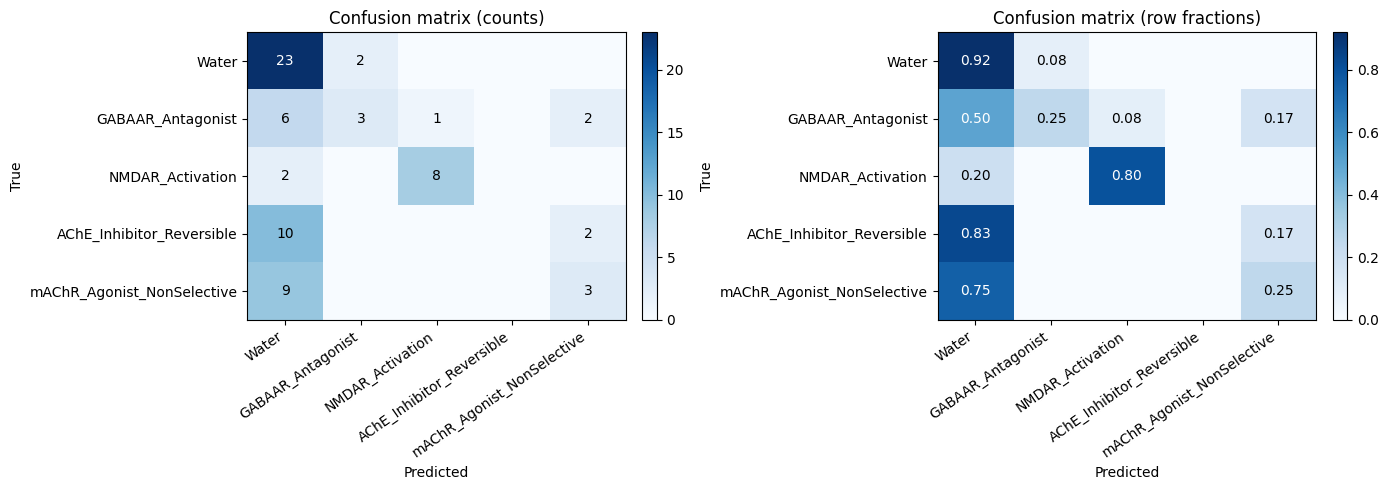


## Holdout report: compound (including control)


,precision,recall,f1-score,support
class,,,,
Control,0.500,0.440000,0.468085,25.0
Bemegride,0.000,0.000000,0.000000,6.0
Bicuculline,0.600,1.000000,0.750000,3.0
Gabazine,0.000,0.000000,0.000000,3.0
(RS)-(Tetrazol-5-yl)glycine,0.500,1.000000,0.666667,3.0
Cis-ACPD,0.000,0.000000,0.000000,3.0
N-methyl-D-aspartate,1.000,0.500000,0.666667,4.0
Donepezil,0.000,0.000000,0.000000,4.0
Galantamine,0.000,0.000000,0.000000,4.0


,value
accuracy,0.338028
macro_precision,0.248077
macro_recall,0.373590
macro_f1,0.250112
weighted_precision,0.330634
weighted_recall,0.338028
weighted_f1,0.308362
n_samples,71.000000
roc_auc_ovr_macro,0.787372
average_precision_macro,0.387734


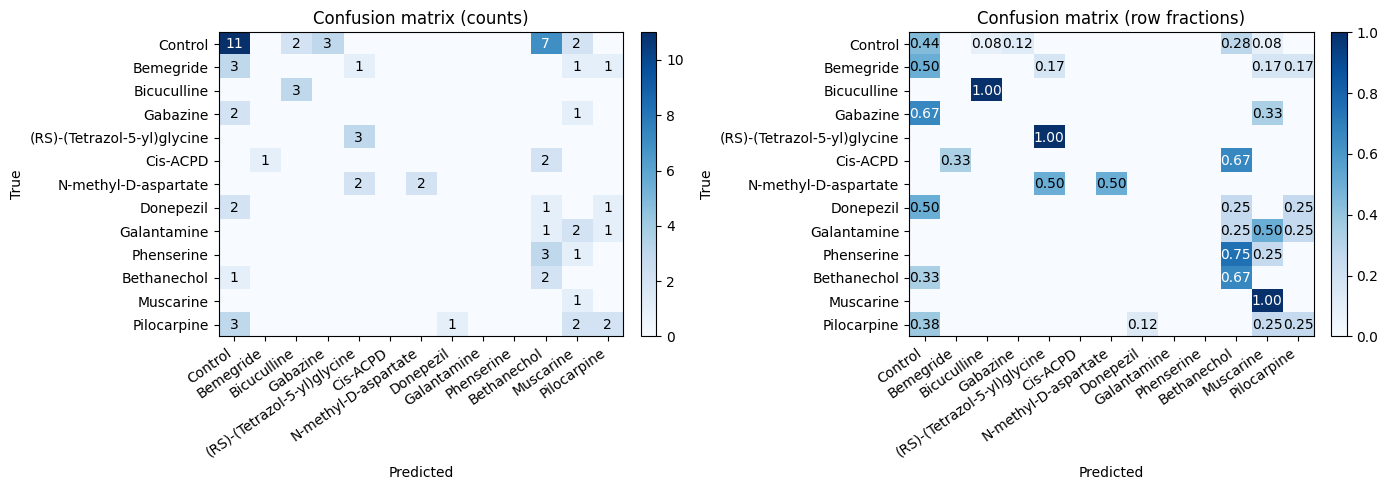


## Holdout report: concentration (including control)


,precision,recall,f1-score,support
class,,,,
control,0.469388,0.920000,0.621622,25.0
high,0.800000,0.160000,0.266667,25.0
mid,0.411765,0.333333,0.368421,21.0


,value
accuracy,0.478873
macro_precision,0.560384
macro_recall,0.471111
macro_f1,0.418903
weighted_precision,0.568757
weighted_recall,0.478873
weighted_f1,0.421747
n_samples,71.000000
roc_auc_ovr_macro,0.643340
average_precision_macro,0.485452


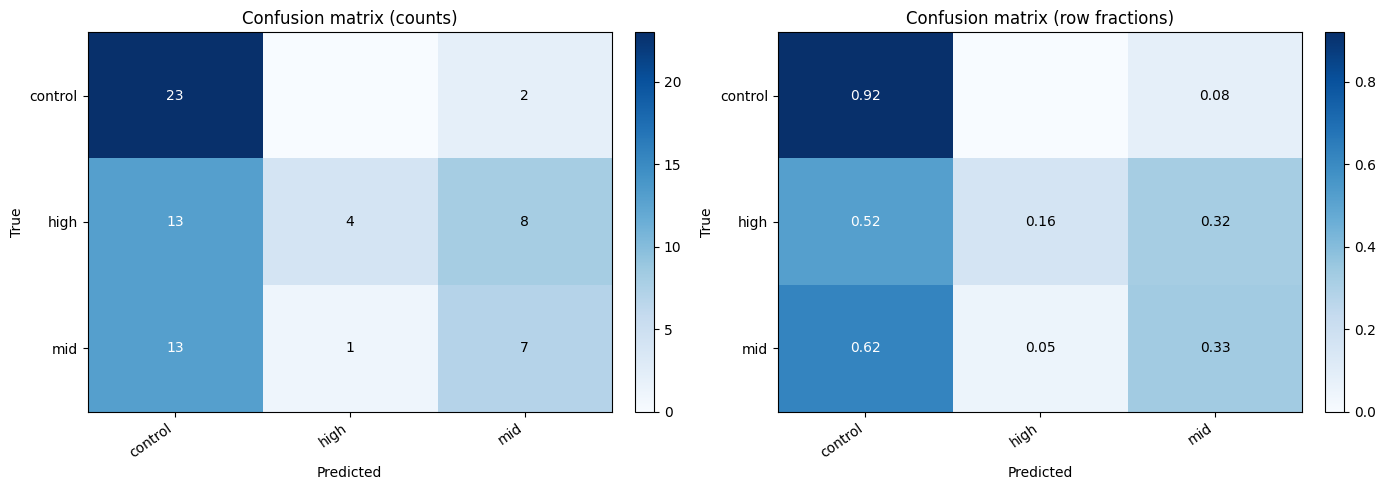


## Holdout report: action (excluding control; probabilities renormalized)


,precision,recall,f1-score,support
class,,,,
GABAAR_Antagonist,0.800000,0.333333,0.470588,12.0
NMDAR_Activation,0.888889,0.800000,0.842105,10.0
AChE_Inhibitor_Reversible,0.333333,0.500000,0.400000,12.0
mAChR_Agonist_NonSelective,0.357143,0.416667,0.384615,12.0


,value
accuracy,0.500000
macro_precision,0.594841
macro_recall,0.512500
macro_f1,0.524327
weighted_precision,0.582057
weighted_recall,0.500000
weighted_f1,0.510511
n_samples,46.000000
roc_auc_ovr_macro,0.772181
average_precision_macro,0.671472


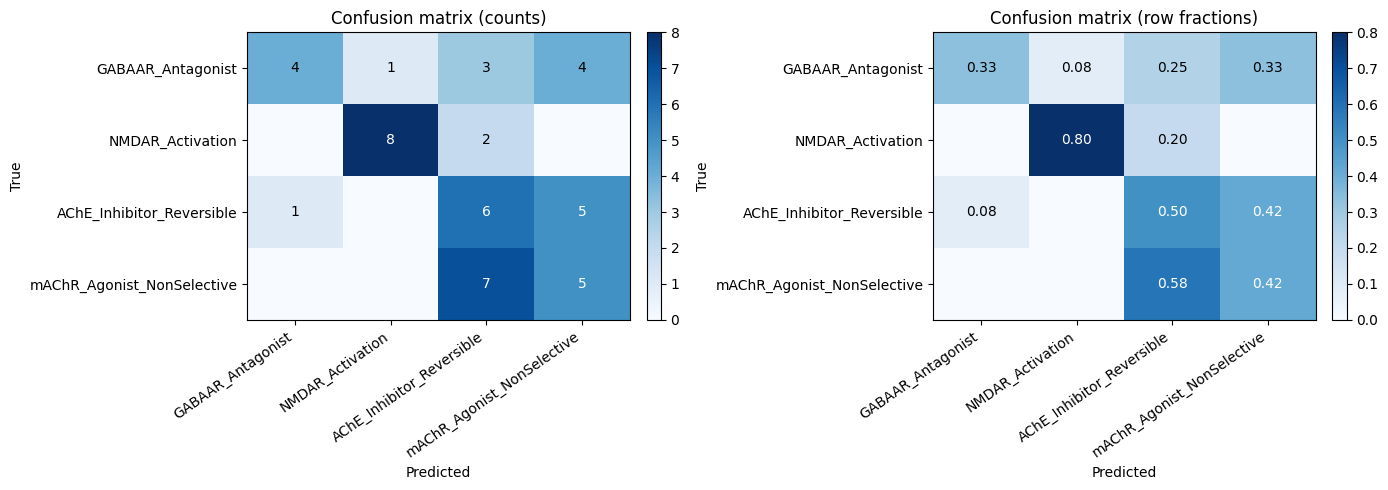


## Holdout report: compound (excluding control; probabilities renormalized)


,precision,recall,f1-score,support
class,,,,
Bemegride,0.000000,0.00,0.000000,6.0
Bicuculline,1.000000,1.00,1.000000,3.0
Gabazine,0.000000,0.00,0.000000,3.0
(RS)-(Tetrazol-5-yl)glycine,0.500000,1.00,0.666667,3.0
Cis-ACPD,0.000000,0.00,0.000000,3.0
N-methyl-D-aspartate,1.000000,0.50,0.666667,4.0
Donepezil,0.500000,0.25,0.333333,4.0
Galantamine,0.000000,0.00,0.000000,4.0
Phenserine,0.000000,0.00,0.000000,4.0


,value
accuracy,0.326087
macro_precision,0.306052
macro_recall,0.416667
macro_f1,0.293962
weighted_precision,0.302924
weighted_recall,0.326087
weighted_f1,0.273190
n_samples,46.000000
roc_auc_ovr_macro,0.831147
average_precision_macro,0.497240


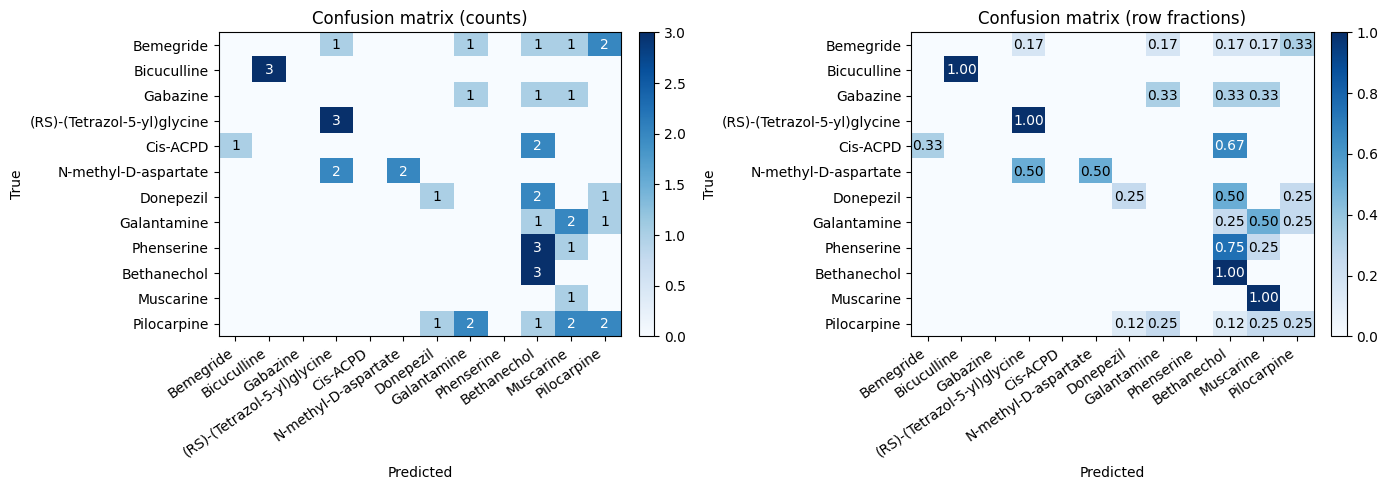


## Holdout report: concentration (excluding control; probabilities renormalized)


,precision,recall,f1-score,support
class,,,,
high,0.619048,0.520000,0.565217,25.0
mid,0.520000,0.619048,0.565217,21.0


,value
accuracy,0.565217
macro_precision,0.569524
macro_recall,0.569524
macro_f1,0.565217
weighted_precision,0.573830
weighted_recall,0.565217
weighted_f1,0.565217
n_samples,46.000000
roc_auc,0.582857
average_precision,0.567466


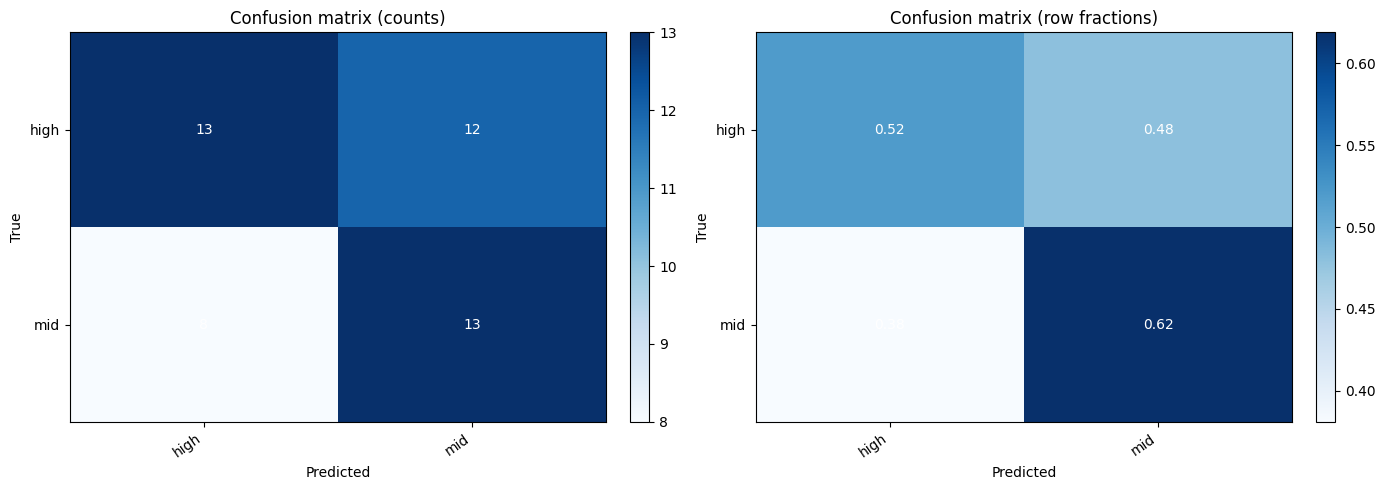

In [84]:
holdout_evaluation = display_holdout_evaluation(model, experiment)


In [85]:
def display_confusion_tables(name: str, y_true: dict, y_pred: dict, class_labels: dict, label_maps: dict) -> None:
    for target in y_true:
        if target not in y_pred:
            continue
        counts_df, fractions_df = build_confusion_matrix_frames(
            y_true[target],
            y_pred[target],
            class_labels=class_labels.get(target),
            label_map=label_maps.get(target),
        )
        print(f"## {name}: {target} confusion counts")
        display(counts_df)
        print(f"## {name}: {target} confusion row fractions")
        display(fractions_df)


display_confusion_tables(
    "Holdout including control",
    experiment.y_true_holdout,
    holdout_evaluation.predictions,
    experiment.class_labels,
    experiment.label_maps,
)

if holdout_evaluation.y_true_excluding_control:
    display_confusion_tables(
        "Holdout excluding control",
        holdout_evaluation.y_true_excluding_control,
        holdout_evaluation.predictions_excluding_control,
        {
            target: [label for label in labels if int(label) != 0]
            for target, labels in experiment.class_labels.items()
            if target in holdout_evaluation.y_true_excluding_control
        },
        {
            target: {label: name for label, name in label_map.items() if int(label) != 0}
            for target, label_map in experiment.label_maps.items()
            if target in holdout_evaluation.y_true_excluding_control
        },
    )


## Holdout including control: action confusion counts


,Water,GABAAR_Antagonist,NMDAR_Activation,AChE_Inhibitor_Reversible,mAChR_Agonist_NonSelective
true_class,,,,,
Water,23,2,0,0,0
GABAAR_Antagonist,6,3,1,0,2
NMDAR_Activation,2,0,8,0,0
AChE_Inhibitor_Reversible,10,0,0,0,2
mAChR_Agonist_NonSelective,9,0,0,0,3


## Holdout including control: action confusion row fractions


,Water,GABAAR_Antagonist,NMDAR_Activation,AChE_Inhibitor_Reversible,mAChR_Agonist_NonSelective
true_class,,,,,
Water,0.920000,0.08,0.000000,0.0,0.000000
GABAAR_Antagonist,0.500000,0.25,0.083333,0.0,0.166667
NMDAR_Activation,0.200000,0.00,0.800000,0.0,0.000000
AChE_Inhibitor_Reversible,0.833333,0.00,0.000000,0.0,0.166667
mAChR_Agonist_NonSelective,0.750000,0.00,0.000000,0.0,0.250000


## Holdout including control: compound confusion counts


...

,Bemegride,Bicuculline,Gabazine,(RS)-(Tetrazol-5-yl)glycine,Cis-ACPD,N-methyl-D-aspartate,Donepezil,Galantamine,Phenserine,Bethanechol,Muscarine,Pilocarpine
true_class,,,,,,,,,,,,
Bemegride,0.000000,0.0,0.0,0.166667,0.0,0.0,0.000,0.166667,0.0,0.166667,0.166667,0.333333
Bicuculline,0.000000,1.0,0.0,0.000000,0.0,0.0,0.000,0.000000,0.0,0.000000,0.000000,0.000000
Gabazine,0.000000,0.0,0.0,0.000000,0.0,0.0,0.000,0.333333,0.0,0.333333,0.333333,0.000000
(RS)-(Tetrazol-5-yl)glycine,0.000000,0.0,0.0,1.000000,0.0,0.0,0.000,0.000000,0.0,0.000000,0.000000,0.000000
Cis-ACPD,0.333333,0.0,0.0,0.000000,0.0,0.0,0.000,0.000000,0.0,0.666667,0.000000,0.000000
N-methyl-D-aspartate,0.000000,0.0,0.0,0.500000,0.0,0.5,0.000,0.000000,0.0,0.000000,0.000000,0.000000
Donepezil,0.000000,0.0,0.0,0.000000,0.0,0.0,0.250,0.000000,0.0,0.500000,0.000000,0.250000
Galantamine,0.000000,0.0,0.0,0.000000,0.0,0.0,0.000,0.000000,0.0,0.250000,0.500000,0.250000
Phenserine,0.000000,0.0,0.0,0.000000,0.0,0.0,0.000,0.000000,0.0,0.750000,0.250000,0.000000


## Holdout excluding control: concentration confusion counts


,high,mid
true_class,,
high,13,12
mid,8,13


## Holdout excluding control: concentration confusion row fractions


,high,mid
true_class,,
high,0.520000,0.480000
mid,0.380952,0.619048


(<Figure size 1550x1050 with 1 Axes>,
 <Axes: title={'center': 'Holdout embedding projection by action (UMAP n_neighbors=15, min_dist=0.1)'}, xlabel='Component 1', ylabel='Component 2'>)

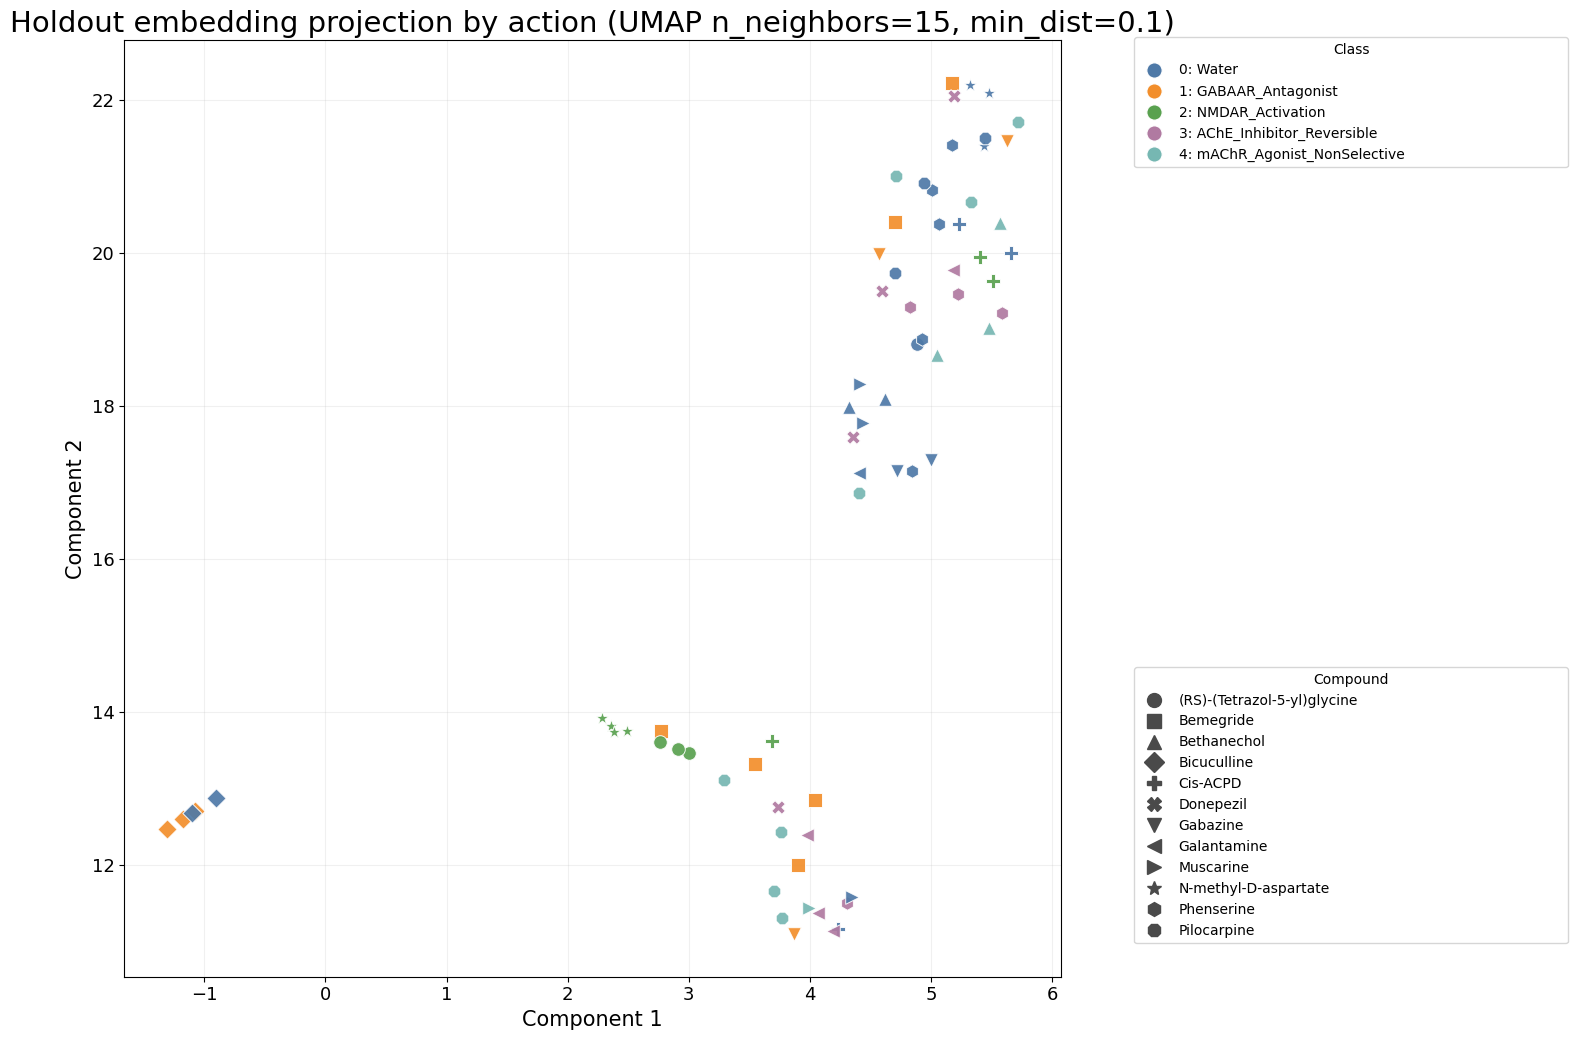

In [86]:
holdout_embedding_projection = build_tensor_embedding_2d(
    model.transform(experiment.splits.X_holdout),
    experiment.y_true_holdout["action"],
    label_map=experiment.label_maps["action"],
    metadata=experiment.splits.metadata_holdout,
    method=umap_method,
    random_state=optimization_config.random_state,
    umap_n_neighbors=umap_n_neighbors,
    umap_min_dist=umap_min_dist,
)
holdout_embedding_projection.to_csv(
    figure_dir / f"{experiment_run.experiment_id}_holdout_embedding_umap.csv",
    index=False,
)
plot_tensor_embedding_2d(
    holdout_embedding_projection,
    title="Holdout embedding projection by action",
    marker_column="compound",
    output_path=figure_dir / f"{experiment_run.experiment_id}_holdout_embedding_umap.pdf",
)


(<Figure size 1550x1050 with 1 Axes>,
 <Axes: title={'center': 'All labeled data embedding projection by action (controls hidden) (UMAP n_neighbors=200, min_dist=0.1)'}, xlabel='Component 1', ylabel='Component 2'>)

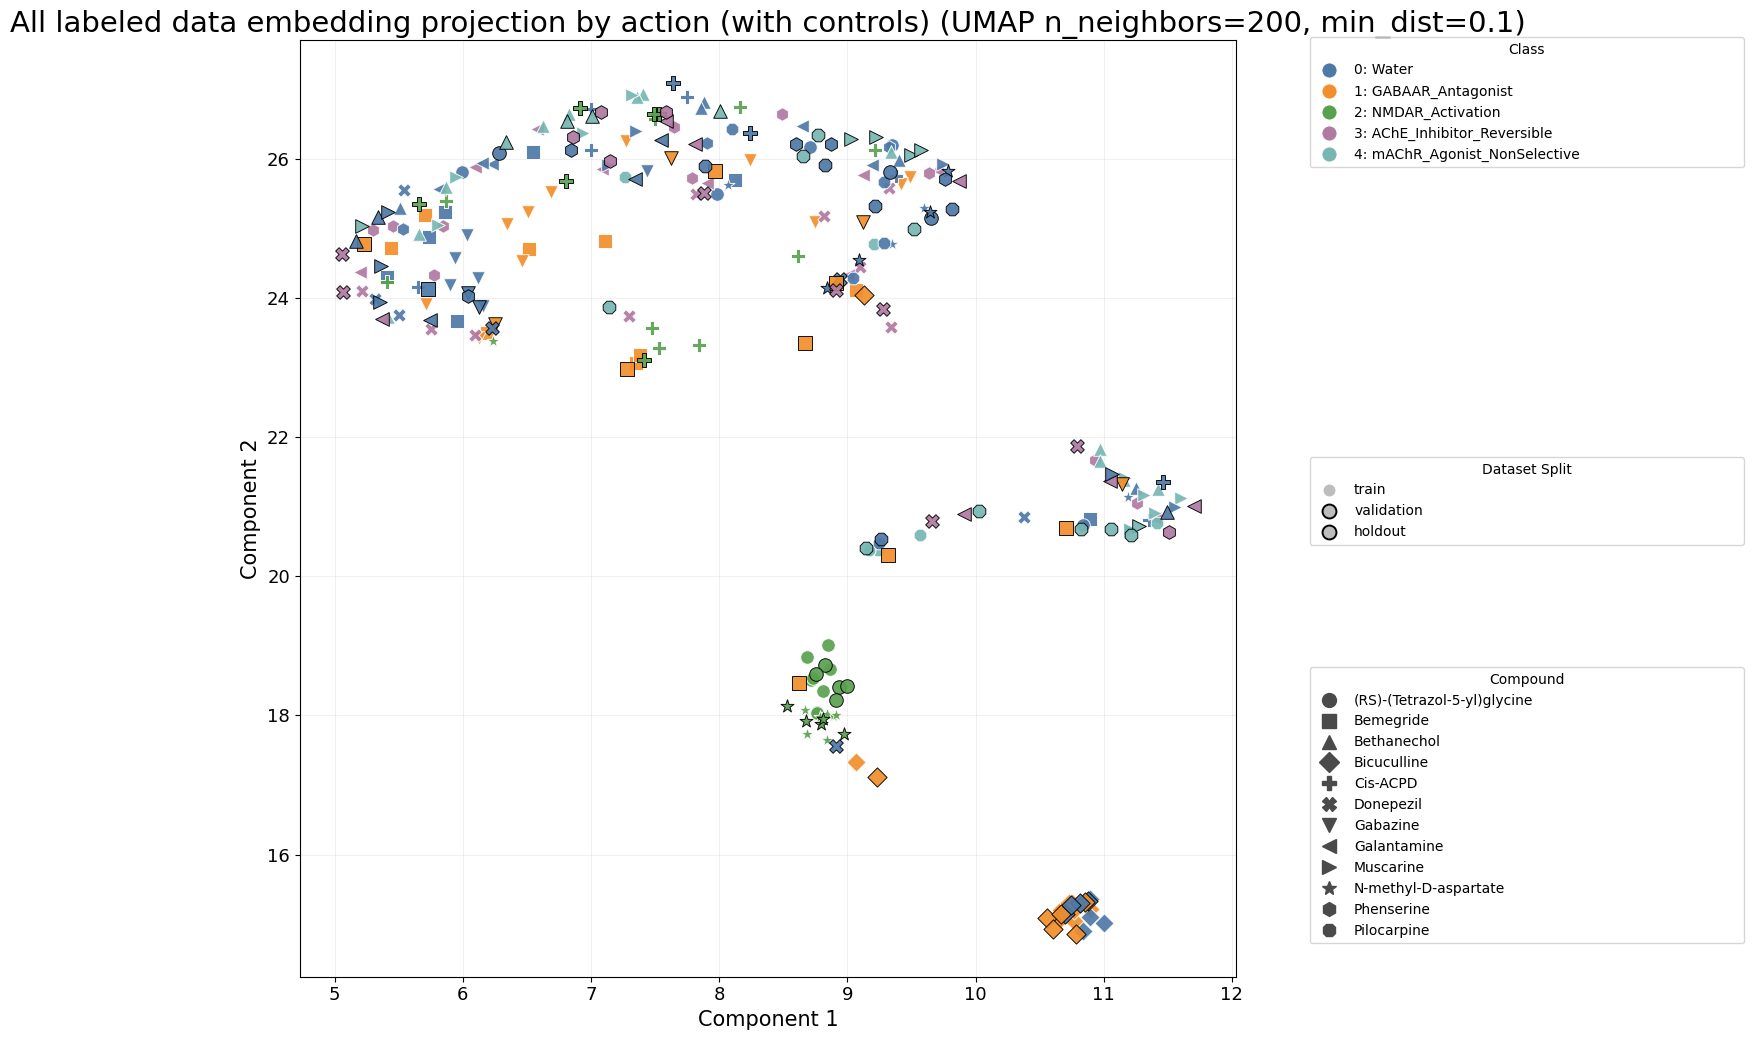

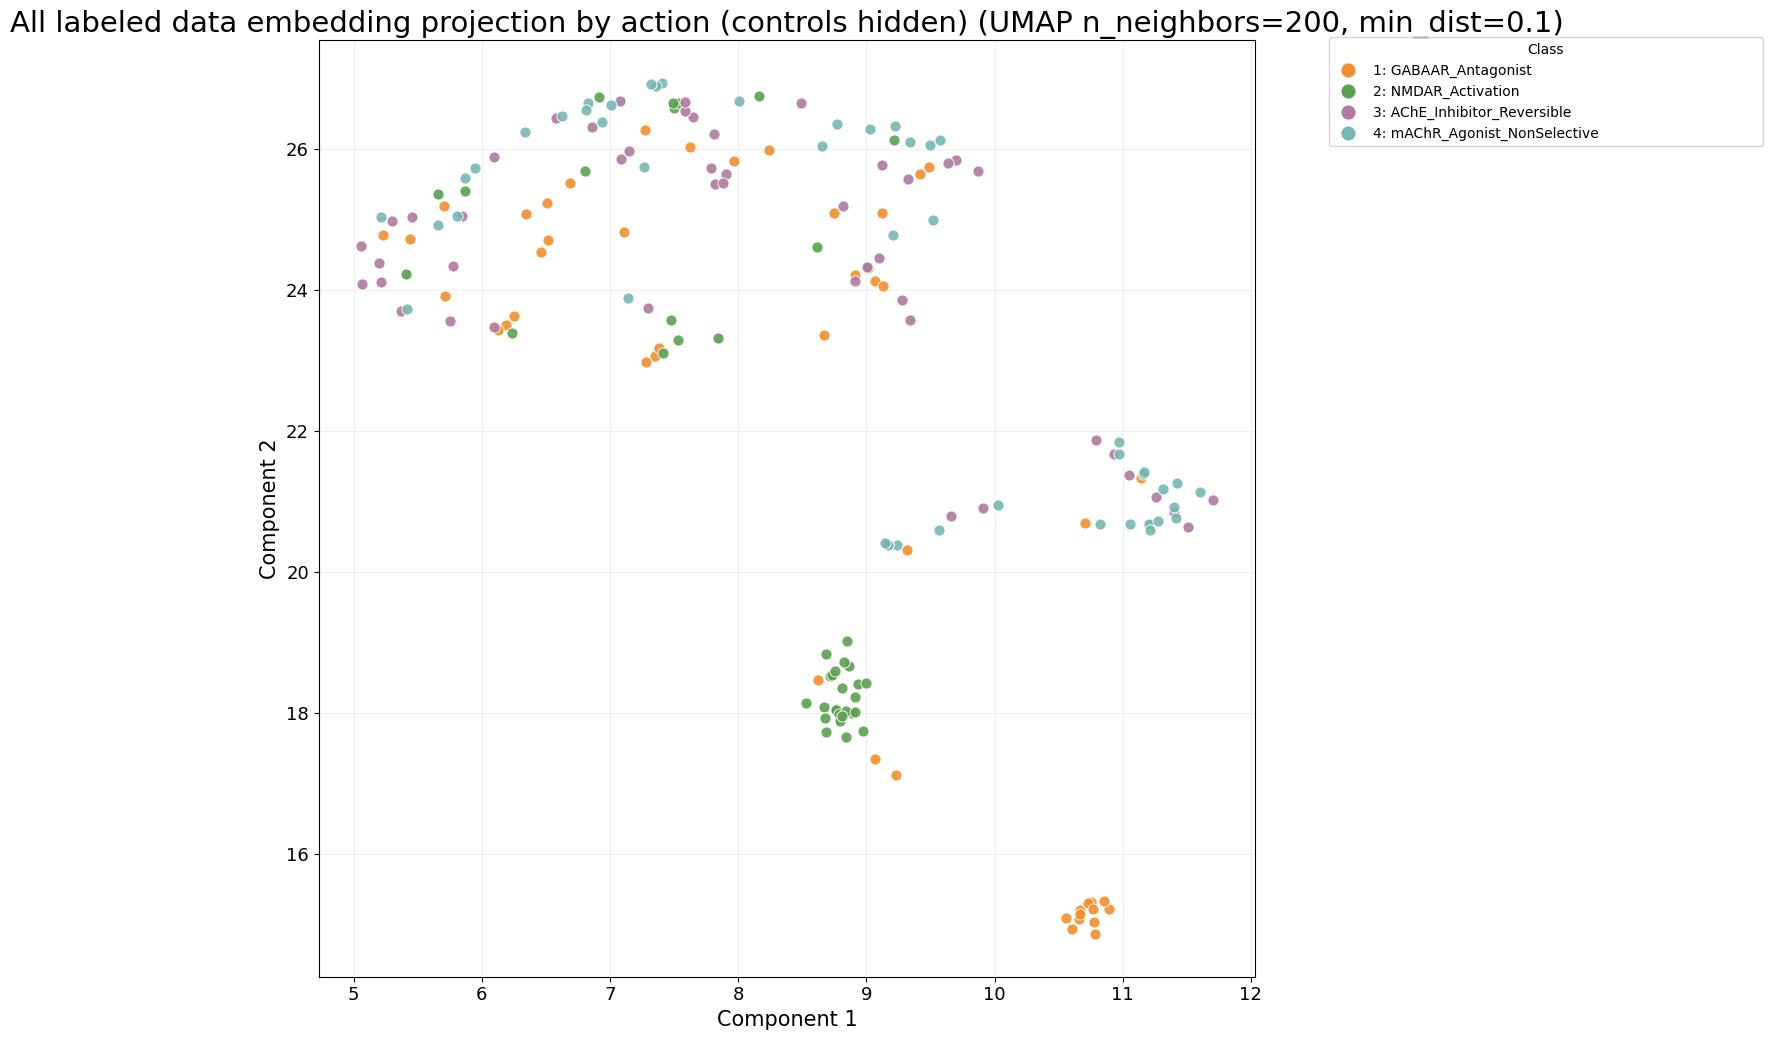

In [87]:
all_labeled_tensors = torch.cat(
    [
        experiment.splits.X_train_base,
        experiment.splits.X_val,
        experiment.splits.X_holdout,
    ],
    dim=0,
)
all_action_labels = torch.cat(
    [
        experiment.splits.y_train_base,
        torch.as_tensor(experiment.splits.y_val),
        torch.as_tensor(experiment.splits.y_holdout),
    ]
).numpy()
all_labeled_metadata = pd.concat(
    [
        experiment.splits.metadata_train_base.assign(dataset_split="train"),
        experiment.splits.metadata_val.assign(dataset_split="validation"),
        experiment.splits.metadata_holdout.assign(dataset_split="holdout"),
    ],
    ignore_index=True,
)

all_embedding_projection = build_tensor_embedding_2d(
    model.transform(all_labeled_tensors),
    all_action_labels,
    label_map=experiment.label_maps["action"],
    metadata=all_labeled_metadata,
    method=umap_method,
    random_state=optimization_config.random_state,
    umap_n_neighbors=200,
    umap_min_dist=umap_min_dist,
)
all_embedding_projection.to_csv(
    figure_dir / f"{experiment_run.experiment_id}_all_labeled_embedding_umap.csv",
    index=False,
)
plot_tensor_embedding_2d(
    all_embedding_projection,
    title="All labeled data embedding projection by action (with controls)",
    marker_column="compound",
    edge_color_column="dataset_split",
    edge_color_map={"train": "white", "validation": "black", "holdout": "black"},
    display_control=True,
    output_path=figure_dir / f"{experiment_run.experiment_id}_all_labeled_embedding_umap_with_controls.pdf",
)
plot_tensor_embedding_2d(
    all_embedding_projection,
    title="All labeled data embedding projection by action (controls hidden)",
    marker_column=None,
    edge_color_column=None,
    edge_color_map={"train": "white", "validation": "black", "holdout": "black"},
    display_control=False,
    output_path=figure_dir / f"{experiment_run.experiment_id}_all_labeled_embedding_umap_controls_hidden.pdf",
)


In [88]:
test_run_config = {
    "source_campaign_trial": latest_trial,
    "source_experiment_id": selected["experiment_id"],
    "source_run_dir": selected["run_dir"],
    "source_checkpoint_path": selected["checkpoint_path"],
    "source_config_path": selected["config_path"],
    "checkpoint_selection_mode": checkpoint_selection_mode,
    "checkpoint_info": checkpoint_info,
    "selection_target": selection_target,
    "selection_metric": selection_metric,
    "selection_score": selected["score"],
    "selection_score_metric": selected["score_metric"],
    "dataset_artifact_path": dataset_artifact_path,
    "test_experiment_id": experiment_run.experiment_id,
    "test_run_dir": Path(experiment_run.run_dir),
    "figure_dir": figure_dir,
    "model_config": asdict(model_config),
    "optimization_config": asdict(optimization_config),
    "loss_weight_config": asdict(loss_weight_config),
}

config_output_path = Path(experiment_run.run_dir) / f"{experiment_run.experiment_id}_config.json"
checkpoint_info_json_path = Path(experiment_run.run_dir) / f"{experiment_run.experiment_id}_checkpoint_info.json"
checkpoint_info_csv_path = Path(experiment_run.run_dir) / f"{experiment_run.experiment_id}_checkpoint_info.csv"

def _json_ready(value):
    if isinstance(value, Path):
        return str(value)
    if isinstance(value, dict):
        return {str(key): _json_ready(item) for key, item in value.items()}
    if isinstance(value, (list, tuple)):
        return [_json_ready(item) for item in value]
    if isinstance(value, np.generic):
        return value.item()
    try:
        if pd.isna(value):
            return None
    except (TypeError, ValueError):
        pass
    return value


config_output_path.write_text(
    json.dumps(_json_ready(test_run_config), indent=2, sort_keys=True),
    encoding="utf-8",
)
checkpoint_info_json_path.write_text(
    json.dumps(_json_ready(checkpoint_info), indent=2, sort_keys=True),
    encoding="utf-8",
)
pd.DataFrame([_json_ready(checkpoint_info)]).to_csv(checkpoint_info_csv_path, index=False)
print(f"Saved test run config: {config_output_path.resolve()}")
print(f"Saved checkpoint info JSON: {checkpoint_info_json_path.resolve()}")
print(f"Saved checkpoint info CSV: {checkpoint_info_csv_path.resolve()}")
print(f"Saved figures in: {figure_dir.resolve()}")


Saved test run config: /run/media/fabrizio/06bb7271-2161-43a4-91f1-98f9b67e9ab2/home/fabrizio/code/ZebraFish/artifacts/nb13C_commutative_cnn_test/runs/13C_test_commutative_cnn_20260731_124607/13C_test_commutative_cnn_20260731_124607_config.json
Saved checkpoint info JSON: /run/media/fabrizio/06bb7271-2161-43a4-91f1-98f9b67e9ab2/home/fabrizio/code/ZebraFish/artifacts/nb13C_commutative_cnn_test/runs/13C_test_commutative_cnn_20260731_124607/13C_test_commutative_cnn_20260731_124607_checkpoint_info.json
Saved checkpoint info CSV: /run/media/fabrizio/06bb7271-2161-43a4-91f1-98f9b67e9ab2/home/fabrizio/code/ZebraFish/artifacts/nb13C_commutative_cnn_test/runs/13C_test_commutative_cnn_20260731_124607/13C_test_commutative_cnn_20260731_124607_checkpoint_info.csv
Saved figures in: /run/media/fabrizio/06bb7271-2161-43a4-91f1-98f9b67e9ab2/home/fabrizio/code/ZebraFish/artifacts/nb13C_commutative_cnn_test/runs/13C_test_commutative_cnn_20260731_124607/figures
